# Tokyo Airbnb Price Analysis
**Author:** Yohei  
**Date:** June 2026  

## Objective
Analyze what drives Airbnb listing prices in Tokyo using 2024 Inside Airbnb data.
Explore price patterns by room type, neighbourhood, and seasonality, then build a regression model to predict price.

## Key Findings
- Median Tokyo Airbnb price: ~¥16,200/night (~$108 USD)
- Entire apartments dominate (85% of listings)
- Central wards (Minato, Chuo, Shinjuku) command highest prices
- April price spike aligns with cherry blossom/Golden Week season
- Ridge regression R²=0.103 — room type and neighbourhood explain ~10% of price variance
- Model underperforms on high-priced listings due to data imbalance (heteroscedasticity)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/listings.csv")
df.shape



(27945, 18)

In [5]:
df.columns.tolist()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'number_of_reviews_ltm',
 'license']

In [6]:
df[['price', 'room_type', 'neighbourhood']].describe()

,price
count,2.548000e+04
mean,2.478188e+04
std,7.786575e+04
min,1.500000e+03
25%,1.120150e+04
50%,1.620000e+04
75%,2.504500e+04
max,9.999998e+06


In [7]:
df["room_type"].value_counts()

room_type
Entire home/apt    23759
Private room        3768
Shared room          281
Hotel room           137
Name: count, dtype: int64

In [8]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             7
neighbourhood_group               27945
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                              2465
minimum_nights                        0
number_of_reviews                     0
last_review                        3936
reviews_per_month                  3936
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                              16
dtype: int64

In [9]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,197677,Oshiage Holiday Apartment,964081,Yoshimi & Marek,NaN,Sumida Ku,35.71707,139.82608,Entire home/apt,12600.0,3,190,2025-08-24,1.11,1,183,10,M130003350
1,776070,Kero-kero room 1F,801494,Kei,NaN,Kita Ku,35.73844,139.76917,Private room,10459.0,3,272,2025-05-21,1.74,1,76,14,M130000243
2,905944,4F Spacious Apartment in Shinjuku / Shibuya Tokyo,4847803,Best Stay In Tokyo!,NaN,Shibuya Ku,35.67878,139.67847,Entire home/apt,33671.0,5,281,2025-09-21,1.85,9,305,50,Hotels and Inns Business Act | 渋谷区保健所長 | 31渋健生...
3,1016831,5 mins Shibuya Cat modern sunny Shimokita,5596383,Wakana,NaN,Setagaya Ku,35.65800,139.67134,Private room,24143.0,1,284,2025-09-21,1.87,1,80,16,M130001107
4,1196177,Homestay at Host's House - Senju-Ohashi Station,5686404,Yukiko,NaN,Adachi Ku,35.74363,139.79852,Private room,8795.0,2,150,2025-09-07,1.01,1,253,25,M130007760


In [16]:
#Data Cleaning

#drop rows with missing price or last_review
df = df.dropna(subset = ["price", "last_review"])

#remove extreme outliers
low = df["price"].quantile(0.01)
high = df["price"].quantile(0.99)
df = df[(df["price"] >= low) & (df["price"] <= high)]

df["last_review"] = pd.to_datetime(df["last_review"])

print(df.shape)
print(df.head())

(19868, 18)
        id                                               name  host_id  \
0   197677                          Oshiage Holiday Apartment   964081   
1   776070                                  Kero-kero room 1F   801494   
2   905944  4F Spacious Apartment in Shinjuku / Shibuya Tokyo  4847803   
3  1016831         5 mins Shibuya Cat modern sunny  Shimokita  5596383   
4  1196177   Homestay at Host's House -  Senju-Ohashi Station  5686404   

             host_name  neighbourhood_group neighbourhood  latitude  \
0      Yoshimi & Marek                  NaN     Sumida Ku  35.71707   
1                  Kei                  NaN       Kita Ku  35.73844   
2  Best Stay In Tokyo!                  NaN    Shibuya Ku  35.67878   
3               Wakana                  NaN   Setagaya Ku  35.65800   
4               Yukiko                  NaN     Adachi Ku  35.74363   

   longitude        room_type    price  minimum_nights  number_of_reviews  \
0  139.82608  Entire home/apt  12600.0 

## EDA ##

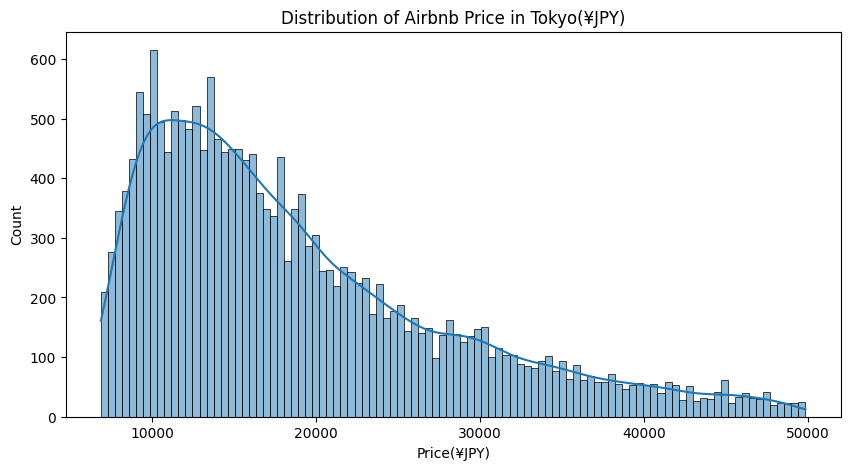

In [17]:
#EDA
plt.figure(figsize = (10,5))
sns.histplot(df['price'],bins = 100, kde = True)
plt.title("Distribution of Airbnb Price in Tokyo(¥JPY)")
plt.xlabel("Price(¥JPY)")
plt.ylabel("Count")
plt.show()

The price distribution is right-skewed, with most listings concentrated between ¥10,000–¥20,000. The long tail suggests a small number of luxury listings pulling the mean up — median is a more representative measure here.

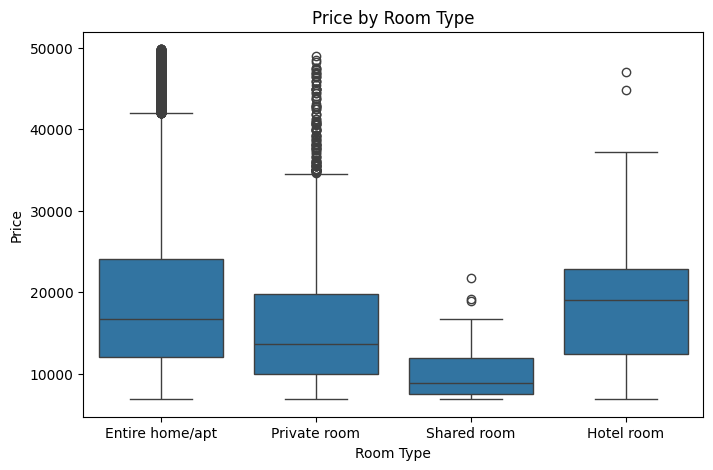

In [19]:
plt.figure(figsize = (8,5))
sns.boxplot(data=df, x = "room_type", y = "price")
plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()

Hotel rooms command the highest median price, while shared rooms are cheapest. Entire apartments show the widest spread, reflecting the mix of budget and luxury options in that category.

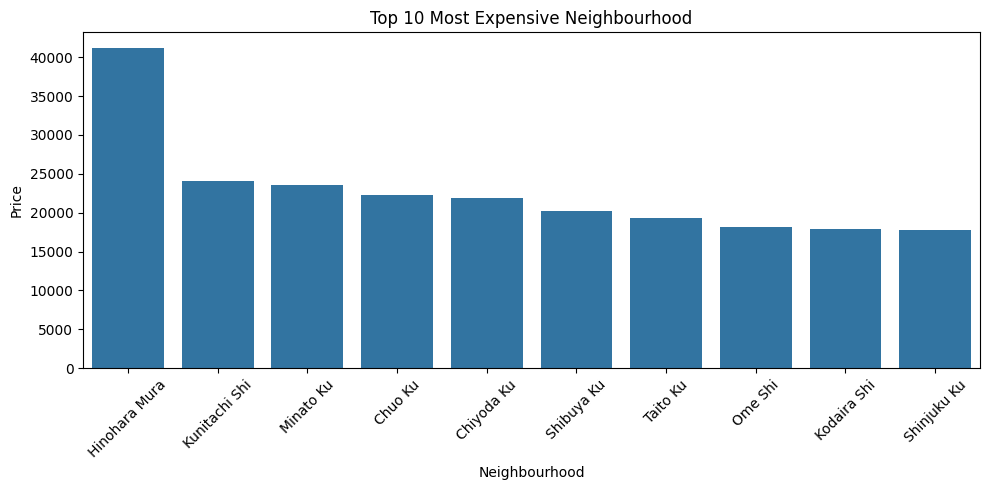

In [30]:
top10_neighbourhood = df.groupby("neighbourhood")["price"].median().sort_values(ascending = False).head(10).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data= top10_neighbourhood, x="neighbourhood", y = "price")
plt.title("Top 10 Most Expensive Neighbourhood")
plt.xlabel("Neighbourhood")
plt.ylabel("Price")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


Hinohara Mura is an outlier — a rural mountain village with few but uniquely priced listings. Among central Tokyo wards, Minato, Chuo, and Shinjuku are consistently the most expensive, as expected.

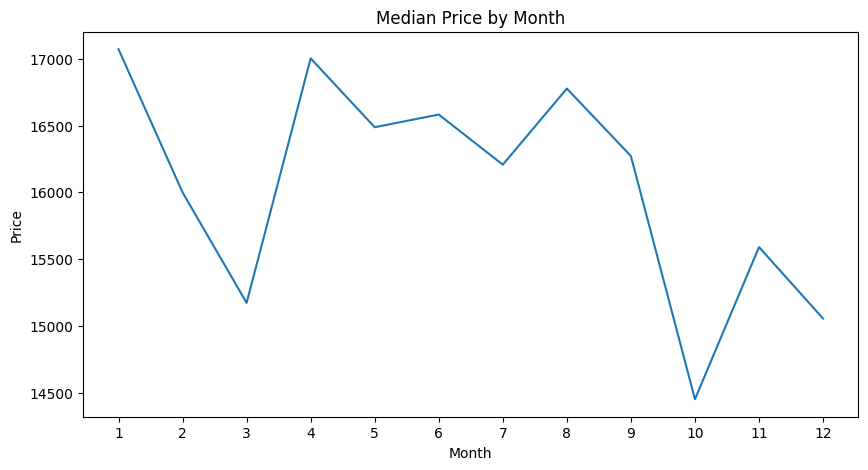

In [31]:
#price over time
df["month"] = df["last_review"].dt.month
monthly_price= df.groupby('month')['price'].median().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data = monthly_price, x = "month", y = "price")
plt.title("Median Price by Month")
plt.xlabel("Month")
plt.ylabel("Price")
plt.xticks(range(1,13))
plt.show()


Prices peak in January and April. The April spike aligns with cherry blossom season and Golden Week — Tokyo's busiest tourist period. 

Note: this uses last_review date as a proxy for booking date, so the signal is approximate.

## ML ##

In [42]:
#ML 
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error

#features and targets
features = ['room_type', 'neighbourhood', 'minimum_nights', 'availability_365', 'reviews_per_month', 'number_of_reviews']
target = 'price'

X = df[features].dropna()
y = df.loc[X.index, target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(15894, 6) (3974, 6)


We split the data 80/20 into training and test sets. Features include room type, neighbourhood, and listing characteristics. Categorical variables are one-hot encoded via a sklearn Pipeline.

In [44]:
#preprocessing
categorical = ['room_type', 'neighbourhood']
numerical = ['minimum_nights', 'availability_365', 'reviews_per_month', 'number_of_reviews']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown="ignore"), categorical),
    ('num', 'passthrough', numerical)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"R²: {r2_score(y_test,y_pred):.3f} JPY")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.0f} JPY")

R²: 0.103 JPY
MAE: 6910 JPY


The model achieves R²=0.103 and MAE=¥6,910. The low R² indicates that room type and neighbourhood alone explain only ~10% of price variance — suggesting that factors like amenities, host reputation, and seasonality play a significant role not captured in this dataset.


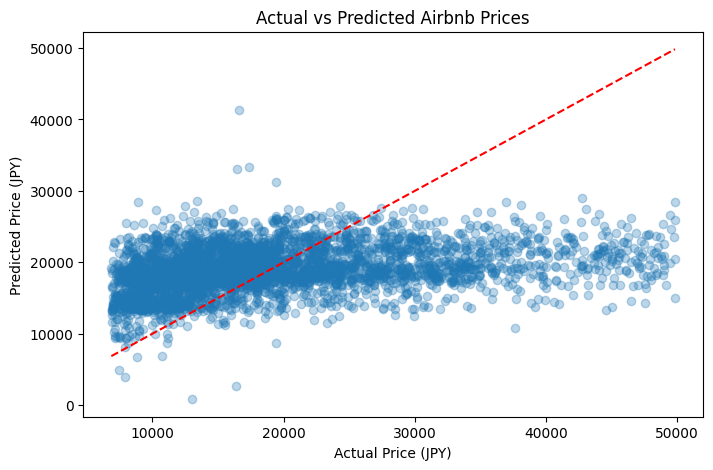

In [45]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price (JPY)')
plt.ylabel('Predicted Price (JPY)')
plt.title('Actual vs Predicted Airbnb Prices')
plt.show()

The model performs reasonably in the ¥10k–¥20k range where most listings cluster, but underperforms on expensive listings. Predictions compress toward the mean — a known limitation of Ridge regression on imbalanced price distributions. A log price transformation or tree-based model would likely improve performance on high-end listings.


## Conclusions & Next Steps

### What we found
- Room type and neighbourhood are significant but insufficient predictors of price
- The model captures general trends but struggles with luxury listings
- Seasonal patterns suggest demand spikes around Japanese holidays (Golden Week, cherry blossom)

### Limitations
- `last_review` used as a date proxy — not actual booking date
- No amenity, host quality, or photo data available in this dataset
- Linear model assumes constant relationships across the price range
- Price is per listing, not per guest — per-person cost comparisons would require occupancy data

### If I were to extend this
- Log-transform price to reduce skew and improve linear model fit
- Try Random Forest or XGBoost for non-linear patterns
- Merge with actual weather/tourism data to quantify seasonal demand effect
- Incorporate review sentiment as a proxy for listing quality